# Classical ML - Data Generation, Preprocessing & Baseline Models
## AI-Based Wage Gap Detection in India
This notebook:
1. Generates a realistic 10,000-worker dataset from government-inspired sources
2. Computes wage gaps against state minimums and education-based fair wages
3. Trains classical ML classifiers as baselines for comparison with QML
4. Saves models and data for use in subsequent notebooks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
print('Libraries loaded. Directories created.')

Libraries loaded. Directories created.


## Part 1: Dataset Generation
Simulates 10,000 Indian workers with demographic and wage attributes.
Gender wage gap is modelled at 15% (female earn less), matching PLFS data.

In [2]:
NUM_WORKERS = 50000

STATES = [
    'Maharashtra', 'Tamil Nadu', 'Karnataka', 'Uttar Pradesh', 'Haryana',
    'Gujarat', 'West Bengal', 'Punjab', 'Chhattisgarh', 'Odisha',
    'Rajasthan', 'Madhya Pradesh', 'Telangana', 'Jharkhand', 'Assam'
]

INDUSTRIES = [
    'Construction', 'Textiles', 'Manufacturing', 'Leather', 'Silk',
    'Mining', 'Agriculture', 'IT Services', 'Retail', 'Food Processing',
    'Chemicals', 'Metals', 'Machinery', 'Small Manufacturing', 'Services'
]

EDUCATION_WAGES = {
    'Illiterate':    7000,
    '5th Pass':      9000,
    '10th Pass':    14000,
    '12th Pass':    18000,
    'Diploma':      22000,
    'Graduate':     32000,
    'Post-Graduate':45000
}

STATE_MIN_WAGES = {
    'Maharashtra': 20400, 'Tamil Nadu': 18000, 'Karnataka': 21600,
    'Uttar Pradesh': 19500, 'Haryana': 20400, 'Gujarat': 21600,
    'West Bengal': 20400, 'Punjab': 18500, 'Chhattisgarh': 22500,
    'Odisha': 17500, 'Rajasthan': 19500, 'Madhya Pradesh': 18000,
    'Telangana': 19500, 'Jharkhand': 17800, 'Assam': 16800
}

# ── Realistic state-wise worker concentration (PLFS 2022-23) ─────────────
# UP + Bihar (not in list, absorbed into UP weight) dominate informal labour
state_probs = np.array([
    0.12,  # Maharashtra   - large formal + informal mix
    0.08,  # Tamil Nadu    - manufacturing hub
    0.07,  # Karnataka     - IT + agriculture
    0.18,  # Uttar Pradesh - largest state, mostly informal
    0.05,  # Haryana       - mixed
    0.07,  # Gujarat       - industrial
    0.07,  # West Bengal   - informal services
    0.04,  # Punjab        - agriculture + small mfg
    0.03,  # Chhattisgarh  - mining + agriculture
    0.04,  # Odisha        - mining + agriculture
    0.06,  # Rajasthan     - informal + agriculture
    0.05,  # Madhya Pradesh
    0.05,  # Telangana     - IT + agriculture
    0.04,  # Jharkhand     - mining heavy
    0.05   # Assam         - agriculture + tea
])
state_probs /= state_probs.sum()

# ── Realistic industry distribution (PLFS 2022-23) ───────────────────────
ind_probs = np.array([
    0.12,  # Construction       - large informal sector
    0.07,  # Textiles
    0.10,  # Manufacturing
    0.03,  # Leather
    0.02,  # Silk
    0.04,  # Mining
    0.20,  # Agriculture        - largest sector by employment (~45% rural)
    0.05,  # IT Services        - smaller but high wage
    0.08,  # Retail
    0.06,  # Food Processing
    0.04,  # Chemicals
    0.04,  # Metals
    0.03,  # Machinery
    0.06,  # Small Manufacturing
    0.06   # Services
])
ind_probs /= ind_probs.sum()

# ── Education probabilities per industry (PLFS/Census correlation) ────────
# Rows = industries (same order as INDUSTRIES list)
# Cols = [Illiterate, 5th Pass, 10th Pass, 12th Pass, Diploma, Graduate, PG]
EDU_BY_INDUSTRY = {
    'Construction'      : [0.25, 0.30, 0.28, 0.12, 0.04, 0.01, 0.00],
    'Textiles'          : [0.15, 0.25, 0.35, 0.18, 0.05, 0.02, 0.00],
    'Manufacturing'     : [0.10, 0.18, 0.30, 0.25, 0.10, 0.06, 0.01],
    'Leather'           : [0.20, 0.28, 0.32, 0.15, 0.04, 0.01, 0.00],
    'Silk'              : [0.18, 0.27, 0.33, 0.16, 0.05, 0.01, 0.00],
    'Mining'            : [0.12, 0.20, 0.32, 0.22, 0.10, 0.03, 0.01],
    'Agriculture'       : [0.35, 0.30, 0.22, 0.10, 0.02, 0.01, 0.00],
    'IT Services'       : [0.00, 0.00, 0.02, 0.08, 0.20, 0.50, 0.20],
    'Retail'            : [0.08, 0.15, 0.30, 0.28, 0.10, 0.08, 0.01],
    'Food Processing'   : [0.15, 0.22, 0.30, 0.20, 0.08, 0.04, 0.01],
    'Chemicals'         : [0.05, 0.10, 0.25, 0.28, 0.18, 0.12, 0.02],
    'Metals'            : [0.08, 0.15, 0.30, 0.27, 0.12, 0.07, 0.01],
    'Machinery'         : [0.05, 0.10, 0.25, 0.28, 0.18, 0.12, 0.02],
    'Small Manufacturing': [0.18, 0.25, 0.30, 0.18, 0.06, 0.02, 0.01],
    'Services'          : [0.05, 0.10, 0.22, 0.28, 0.15, 0.15, 0.05],
}

# ── Gender probability per industry (PLFS gender segregation data) ────────
# P(Female) per industry
FEMALE_PROB_BY_INDUSTRY = {
    'Construction'      : 0.12,  # male-dominated
    'Textiles'          : 0.68,  # female-dominated
    'Manufacturing'     : 0.28,
    'Leather'           : 0.55,  # female-dominated
    'Silk'              : 0.72,  # female-dominated
    'Mining'            : 0.08,  # very male-dominated
    'Agriculture'       : 0.42,  # near-equal, women do more unpaid work
    'IT Services'       : 0.32,
    'Retail'            : 0.25,
    'Food Processing'   : 0.45,
    'Chemicals'         : 0.22,
    'Metals'            : 0.10,
    'Machinery'         : 0.12,
    'Small Manufacturing': 0.38,
    'Services'          : 0.48,
}

# ── Experience skew per industry ─────────────────────────────────────────
# (mean_years, std_years) — informal sectors have younger/less experienced workers
EXP_BY_INDUSTRY = {
    'Construction'      : (8,  6),
    'Textiles'          : (10, 7),
    'Manufacturing'     : (12, 8),
    'Leather'           : (9,  6),
    'Silk'              : (9,  6),
    'Mining'            : (11, 7),
    'Agriculture'       : (15, 9),  # older workforce
    'IT Services'       : (6,  4),  # younger workforce
    'Retail'            : (8,  6),
    'Food Processing'   : (10, 7),
    'Chemicals'         : (12, 8),
    'Metals'            : (13, 8),
    'Machinery'         : (12, 8),
    'Small Manufacturing': (9, 6),
    'Services'          : (9,  7),
}

# ── Generate workers with realistic correlations ──────────────────────────
edu_levels = list(EDUCATION_WAGES.keys())

rows = []
for i in range(NUM_WORKERS):
    # 1. Pick state and industry
    state    = np.random.choice(STATES,     p=state_probs)
    industry = np.random.choice(INDUSTRIES, p=ind_probs)

    # 2. Education correlated with industry
    edu_p = np.array(EDU_BY_INDUSTRY[industry], dtype=float)
    edu_p /= edu_p.sum()
    education = np.random.choice(edu_levels, p=edu_p)

    # 3. Gender correlated with industry
    female_p = FEMALE_PROB_BY_INDUSTRY[industry]
    gender   = 'Female' if np.random.random() < female_p else 'Male'

    # 4. Experience correlated with industry (clipped 0-35)
    mean_exp, std_exp = EXP_BY_INDUSTRY[industry]
    experience = int(np.clip(np.random.normal(mean_exp, std_exp), 0, 35))

    # 5. Wage: base + experience premium ± noise + gender penalty
    base = EDUCATION_WAGES[education]
    wage = (base + experience * 300) * np.random.uniform(0.80, 1.20)
    if gender == 'Female':
        wage *= 0.85

    rows.append({
        'worker_id'          : i + 1,
        'state'              : state,
        'industry'           : industry,
        'gender'             : gender,
        'education_level'    : education,
        'experience_years'   : experience,
        'actual_monthly_wage': int(wage)
    })

df = pd.DataFrame(rows)

print(f'Dataset shape: {df.shape}')
print(f'\nIndustry distribution:')
print((df['industry'].value_counts(normalize=True)*100).round(1).to_string())
print(f'\nGender by industry (% Female):')
print((df.groupby('industry')['gender']
         .apply(lambda x: (x=="Female").mean()*100)
         .round(1)).to_string())
print(f'\nEducation by industry (top level %):')
print(df.groupby(['industry','education_level']).size()
        .groupby(level=0, group_keys=False)
        .apply(lambda x: x.nlargest(1)).to_string())


Dataset shape: (50000, 7)

Industry distribution:
industry
Agriculture            20.1
Construction           12.3
Manufacturing           9.9
Retail                  8.0
Textiles                6.9
Small Manufacturing     6.1
Food Processing         6.0
Services                6.0
IT Services             4.8
Mining                  4.0
Metals                  4.0
Chemicals               4.0
Leather                 3.0
Machinery               2.9
Silk                    2.0

Gender by industry (% Female):
industry
Agriculture            41.9
Chemicals              23.1
Construction           12.0
Food Processing        44.9
IT Services            31.7
Leather                54.4
Machinery              10.6
Manufacturing          28.7
Metals                  9.2
Mining                  7.0
Retail                 25.4
Services               49.4
Silk                   70.8
Small Manufacturing    38.2
Textiles               67.8

Education by industry (top level %):
industry             e

## Part 2: Wage Gap Calculation

In [3]:
df['min_wage_standard'] = df['state'].map(STATE_MIN_WAGES)
df['fair_wage_estimate'] = df['education_level'].map(EDUCATION_WAGES)

df['wage_gap']          = df['min_wage_standard'] - df['actual_monthly_wage']
df['gap_percentage']    = (df['wage_gap'] / df['min_wage_standard'] * 100).round(2)
df['is_underpaid']      = (df['actual_monthly_wage'] < df['min_wage_standard']).astype(int)

df['fair_wage_gap']     = df['fair_wage_estimate'] - df['actual_monthly_wage']
df['fair_wage_gap_pct'] = (df['fair_wage_gap'] / df['fair_wage_estimate'] * 100).round(2)

# Gender disparity flag: female earning < 85% of average male wage in same industry
male_avg = df[df['gender']=='Male']['actual_monthly_wage'].mean()
df['gender_discriminated'] = (
    (df['gender'] == 'Female') &
    (df['actual_monthly_wage'] < male_avg * 0.85)
).astype(int)

print('=== Dataset Summary ===')
print(f'Total workers     : {len(df):,}')
print(f'Underpaid workers : {df["is_underpaid"].sum():,} ({df["is_underpaid"].mean()*100:.1f}%)')
print(f'Gender gap flag   : {df["gender_discriminated"].sum():,}')
print(f'\nAverage wage by gender:')
print(df.groupby('gender')['actual_monthly_wage'].mean().round(0))

df.to_csv('data/wage_gap_data.csv', index=False)
print('\nData saved to data/wage_gap_data.csv')

=== Dataset Summary ===
Total workers     : 50,000
Underpaid workers : 35,285 (70.6%)
Gender gap flag   : 10,113

Average wage by gender:
gender
Female    15142.0
Male      18104.0
Name: actual_monthly_wage, dtype: float64

Data saved to data/wage_gap_data.csv


## Part 3: Feature Engineering & Preprocessing

In [4]:
le_gender    = LabelEncoder()
le_education = LabelEncoder()
le_state     = LabelEncoder()
le_industry  = LabelEncoder()

df['gender_enc']    = le_gender.fit_transform(df['gender'])
df['education_enc'] = le_education.fit_transform(df['education_level'])
df['state_enc']     = le_state.fit_transform(df['state'])
df['industry_enc']  = le_industry.fit_transform(df['industry'])

# Features: gender, education, experience, actual wage, state, industry
FEATURES = ['gender_enc','education_enc','experience_years',
            'actual_monthly_wage','state_enc','industry_enc']
TARGET   = 'is_underpaid'

X = df[FEATURES]
y = df[TARGET]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')
print(f'Class balance (train): {pd.Series(y_train).value_counts().to_dict()}')

Training set : (40000, 6)
Test set     : (10000, 6)
Class balance (train): {1: 28228, 0: 11772}


## Part 4: Train Classical ML Models

In [5]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]
    metrics = {
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_proba)
    }
    print(f'{name:25s} | Acc={metrics["Accuracy"]:.4f}  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')
    return model, metrics

print(f'{"Model":25s} | {"Accuracy":10s} {"F1":10s} {"ROC-AUC"}')
print('-'*60)

model_lr, metrics_lr = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test
)

model_rf, metrics_rf = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

model_gb, metrics_gb = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=150, random_state=42),
    X_train, y_train, X_test, y_test
)

ensemble = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('rf', RandomForestClassifier(n_estimators=150, random_state=42)),
                ('gb', GradientBoostingClassifier(n_estimators=150, random_state=42))],
    voting='soft'
)
model_ens, metrics_ens = evaluate_model(
    'Ensemble (LR+RF+GB)',
    ensemble,
    X_train, y_train, X_test, y_test
)

results = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'Random Forest'      : metrics_rf,
    'Gradient Boosting'  : metrics_gb,
    'Ensemble'           : metrics_ens
}).T
results.to_csv('outputs/classical_model_results.csv')

Model                     | Accuracy   F1         ROC-AUC
------------------------------------------------------------
Logistic Regression       | Acc=0.9509  F1=0.9656  AUC=0.9903
Random Forest             | Acc=0.9924  F1=0.9946  AUC=0.9997
Gradient Boosting         | Acc=0.9997  F1=0.9998  AUC=0.9999
Ensemble (LR+RF+GB)       | Acc=0.9957  F1=0.9970  AUC=0.9998


## Part 5: Feature Importance Analysis

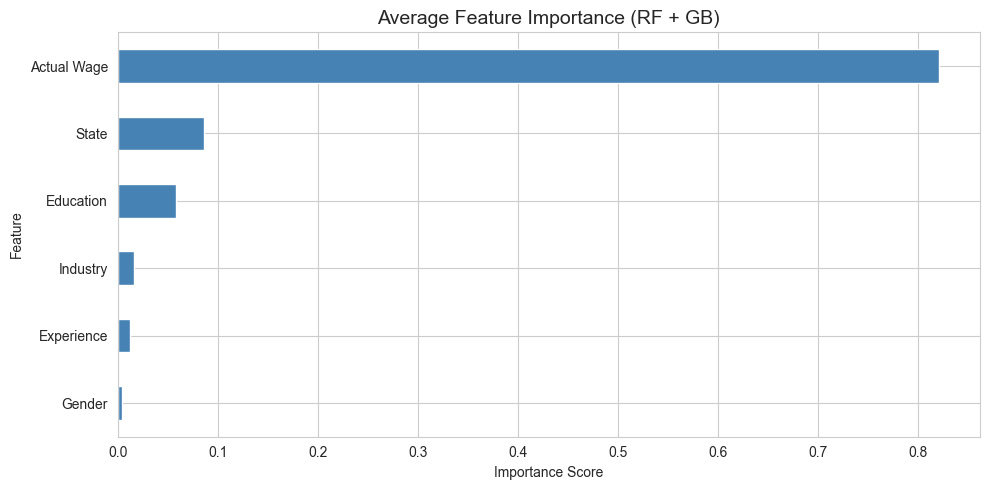

             Random Forest  Grad Boosting  Average
Feature                                           
Gender              0.0096         0.0000   0.0048
Experience          0.0248         0.0000   0.0124
Industry            0.0337         0.0000   0.0168
Education           0.1175         0.0000   0.0587
State               0.0902         0.0832   0.0867
Actual Wage         0.7243         0.9167   0.8205


In [6]:
feature_names = ['Gender','Education','Experience','Actual Wage','State','Industry']

importances = pd.DataFrame({
    'Feature'       : feature_names,
    'Random Forest' : model_rf.feature_importances_,
    'Grad Boosting' : model_gb.feature_importances_
}).set_index('Feature')
importances['Average'] = importances.mean(axis=1)
importances = importances.sort_values('Average', ascending=True)

fig, ax = plt.subplots(figsize=(10,5))
importances['Average'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Average Feature Importance (RF + GB)', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=120)
plt.show()
print(importances.round(4))

## Part 6: Save Everything for Downstream Notebooks

In [7]:
pickle.dump(model_lr,  open('models/logistic_model.pkl','wb'))
pickle.dump(model_rf,  open('models/random_forest_model.pkl','wb'))
pickle.dump(model_gb,  open('models/gradient_boosting_model.pkl','wb'))
pickle.dump(model_ens, open('models/ensemble_model.pkl','wb'))
pickle.dump(le_gender,    open('models/le_gender.pkl','wb'))
pickle.dump(le_education, open('models/le_education.pkl','wb'))
pickle.dump(le_state,     open('models/le_state.pkl','wb'))
pickle.dump(le_industry,  open('models/le_industry.pkl','wb'))
pickle.dump(scaler,       open('models/scaler.pkl','wb'))
pickle.dump(FEATURES,     open('models/feature_names.pkl','wb'))

# Save test split
pd.DataFrame(X_test, columns=FEATURES).to_csv('data/X_test.csv', index=False)
pd.Series(y_test.values, name='is_underpaid').to_csv('data/y_test.csv', index=False)

print('All models, encoders, scalers and test data saved.')
print(f'\nBest classical model: {results["Accuracy"].idxmax()} '
      f'(Accuracy={results["Accuracy"].max():.4f})')

All models, encoders, scalers and test data saved.

Best classical model: Gradient Boosting (Accuracy=0.9997)
